In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving credit_dataset_5000_enhanced_final.csv to credit_dataset_5000_enhanced_final (3).csv


In [ ]:
df = pd.read_csv("credit_dataset_5000_enhanced_final.csv")

In [ ]:
df.head()

,Age,Income,Coapplicant_Income,Dependents,Employ_Status,Debt,PrevLDefault,CIBIL_Score,Loan_Approval
0,61,26587,10296,1,Employed,56824,1,465,0
1,36,23236,13264,3,Self-employed,78620,1,456,1
2,66,19245,32648,5,Employed,34596,0,572,0
3,29,64148,19563,1,Employed,59612,0,620,0
4,43,101424,49221,1,Unemployed,1523,0,659,0


In [ ]:
print(df.isnull().sum())

Age                   0
Income                0
Coapplicant_Income    0
Dependents            0
Employ_Status         0
Debt                  0
PrevLDefault          0
CIBIL_Score           0
Loan_Approval         0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


In [ ]:
np.random.seed(42)

In [ ]:
score = (
    (df['CIBIL_Score'] - df['CIBIL_Score'].mean()) / df['CIBIL_Score'].std() * 2.5
    - df['PrevLDefault'] * 0.0          # removed - it's ~-0.91 correlated with CIBIL_Score already
    - (df['Debt'] / df['Income'].replace(0, np.nan).fillna(df['Income'].mean())) * 0.8
    + (df['Income'] - df['Income'].mean()) / df['Income'].std() * 1.3
    - df['Dependents'] * 0.1
    + np.where(df['Employ_Status'] == 'Employed', 2.0,
        np.where(df['Employ_Status'] == 'Self-employed', 2.2, -2.0))
)

In [ ]:
threshold = score.median()

In [ ]:
df["Loan_Approval"] = (
    score > threshold
).astype(int)

In [ ]:
X = df.drop("Loan_Approval", axis=1)

In [ ]:
y = df["Loan_Approval"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.3,
random_state=42,
stratify=y
)

In [ ]:
dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=10,
                       random_state=42)

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy*100)

Accuracy: 95.8


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[714  36]
 [ 27 723]]


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       750
           1       0.95      0.96      0.96       750

    accuracy                           0.96      1500
   macro avg       0.96      0.96      0.96      1500
weighted avg       0.96      0.96      0.96      1500



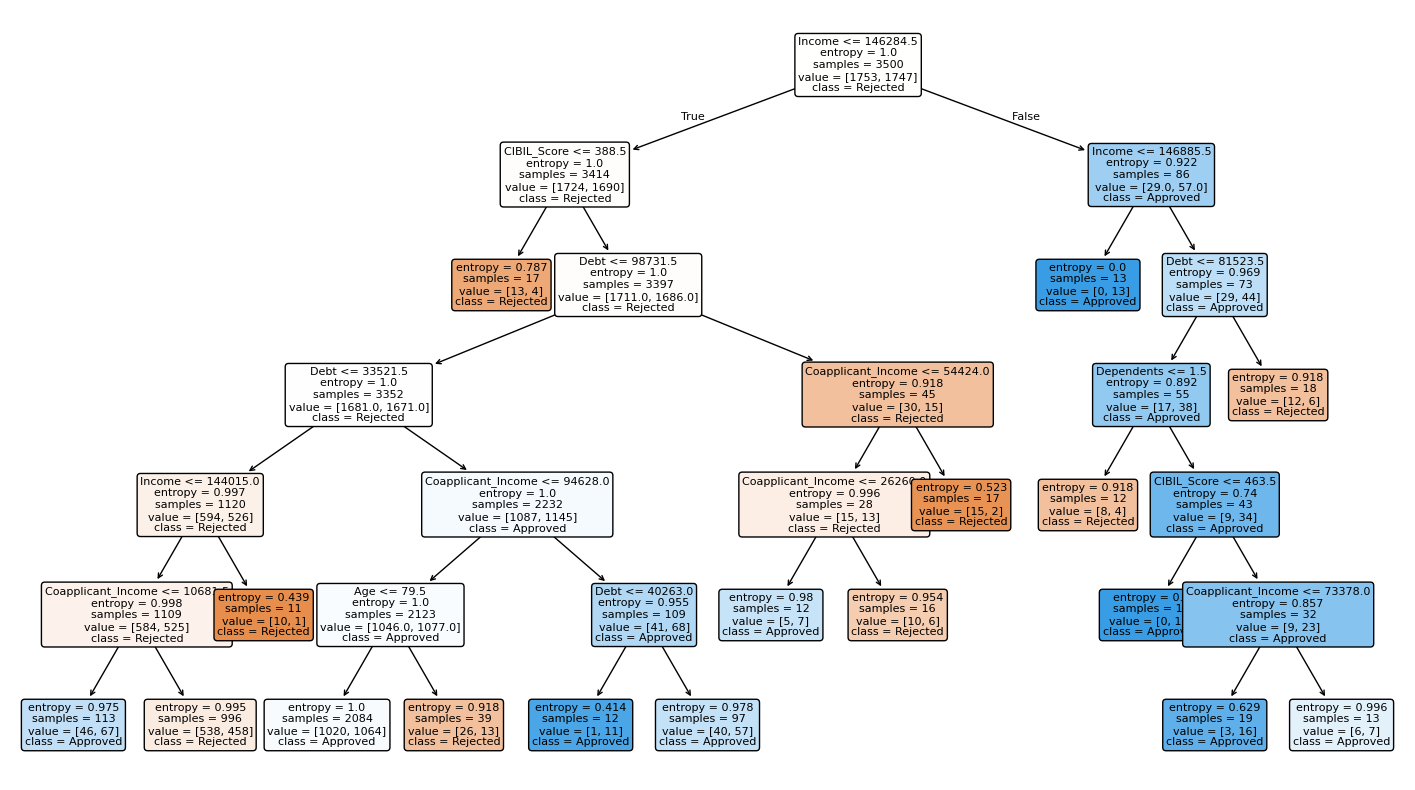

In [ ]:
plt.figure(figsize=(18,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})


importance = importance.sort_values(by="Importance", ascending=False)


print(importance)

              Feature  Importance
7         CIBIL_Score    0.657426
1              Income    0.309015
5                Debt    0.033559
0                 Age    0.000000
3          Dependents    0.000000
2  Coapplicant_Income    0.000000
4       Employ_Status    0.000000
6        PrevLDefault    0.000000


In [ ]:
print(
    "Train Accuracy:",
    accuracy_score(
        y_train,
        dt.predict(X_train)
    )
)

print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

Train Accuracy: 0.9725714285714285
Test Accuracy: 0.958
